# 常用激活函数和损失函数详解  
>激活函数和损失函数是深度学习模型中重要组成部分，激活函数和损失函数的选择很大程度上决定了深度神经网络的性能和精度，需要根据具体问题的特点和数据分布等因素进行选择。在本节中，将介绍深度学习中常见的激活函数和损失函数，并说明不同函数的常见应用场景。

## 1. 常用激活函数  
使用激活函数可以实现网络的高度非线性，这对于建模输入和输出之间的复杂关系非常关键。如果没有非线性激活函数，那么该网络将仅仅能够表达简单的线性映射，即便有再多的隐藏层，其整个网络跟单层神经网络也是等价的，只有加入了非线性激活函数之后，深度神经网络才具备了令人惊异的非线性映射学习能力，可以在网络中的多个层中应用激活函数。

### 1.1 Sigmoid激活函数  
sigmoid 是使用范围最广的一类激活函数，其取值范围为 [0, 1]，它可以将一个实数映射到 [0, 1] 的区间，可以将其用于二分类问题。  



$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

使用python实现这个函数：

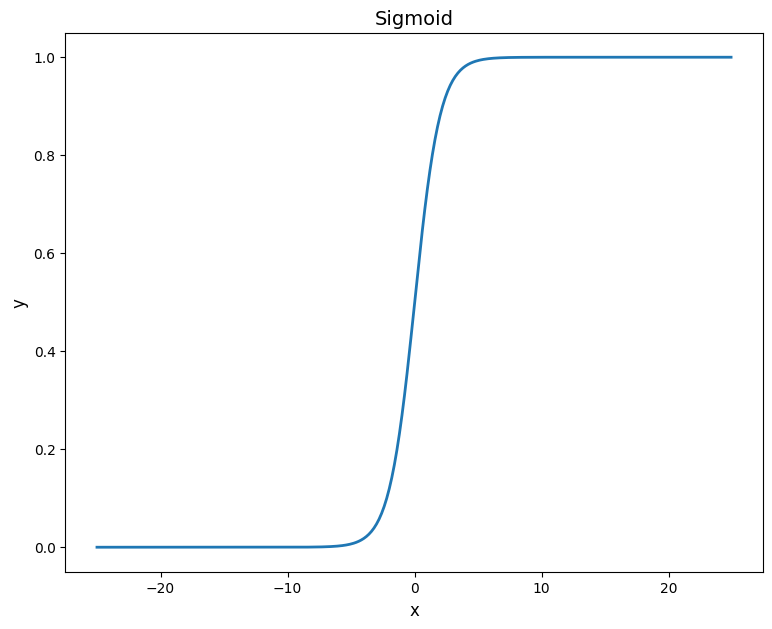

In [26]:
def sigmoid(x):
    return 1/(1+np.exp(-x)) 
     
#绘制代码：
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义 Sigmoid 函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. 生成 x 轴数据（从 -25 到 25，步长 0.1）
x = np.arange(-25, 25, 0.1)
y = sigmoid(x)

# 3. 绘制图像
plt.figure(figsize=(9, 7))
plt.plot(x, y, color='#1f77b4', linewidth=2)

# 4. 设置图表标题和坐标轴标签
plt.title('Sigmoid', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)

# 5. 设置 y 轴范围和刻度
plt.ylim(-0.05, 1.05)
plt.yticks(np.arange(0, 1.1, 0.2))

# 6. 显示网格和图像
plt.grid(False)
plt.show()

- 优点：平滑、易于求导。
- 缺点：反向传播求导涉及除法，因此计算量大；反向传播时，很容易就会出现梯度消失的情况，从而限制了深层网络的训练。

### 1.2 Tanh激活函数  
Tanh 是双曲函数的一种，其是 Sigmoid 激活函数的改进，是以零为中心的对称函数，其取值范围为 [-1, 1]。Tanh 激活函数计算公式如下：


$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} = 2\sigma(2x) - 1 $$

使用python实现此函数：

In [27]:
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

函数图像如下所示，它在开区间 (-1, 1) 内是单调递增的奇函数，函数图形关于原点对称：

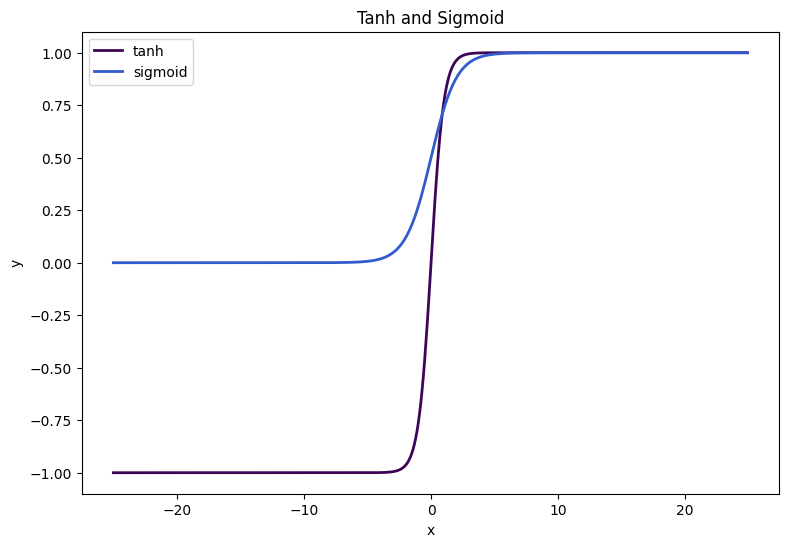

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 定义函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

# 生成数据
x = np.arange(-25, 25, 0.1)
y_tanh = tanh(x)
y_sigmoid = sigmoid(x)

# 绘图
plt.figure(figsize=(9, 6))
plt.plot(x, y_tanh, color="#3e0457", linewidth=2, label='tanh')  # 紫色
plt.plot(x, y_sigmoid, color="#325bcd", linewidth=2, label='sigmoid')  # 绿色

# 设置图表
plt.title('Tanh and Sigmoid', fontsize=12)
plt.xlabel('x', fontsize=10)
plt.ylabel('y', fontsize=10)
plt.ylim(-1.1, 1.1)
plt.legend(loc='upper left')
plt.grid(False)

# 显示
plt.show()

- 优点：tanh 函数是 sigmoid 函数的改进，收敛速度快，不易出现 loss 值晃动。  
- 缺点：无法解决梯度弥散的问题，函数的计算量同样是指数级的，计算相对复杂

### 1.3 ReLU激活函数  
修正线性单元 (Rectified Linear Units, ReLU) 激活函数是 sigmoid 和 tanh 激活函数的完美替代激活函数，是深度学习领域最重要的突破技术之一。ReLU 激活函数计算公式如下：

$$
\text{relu}(x) =
\begin{cases}
0, & x < 0 \\
x, & x \ge 0
\end{cases}
$$

使用Python实现此函数：

In [29]:
def relu(x):
    return np.where(x>0, x, 0)

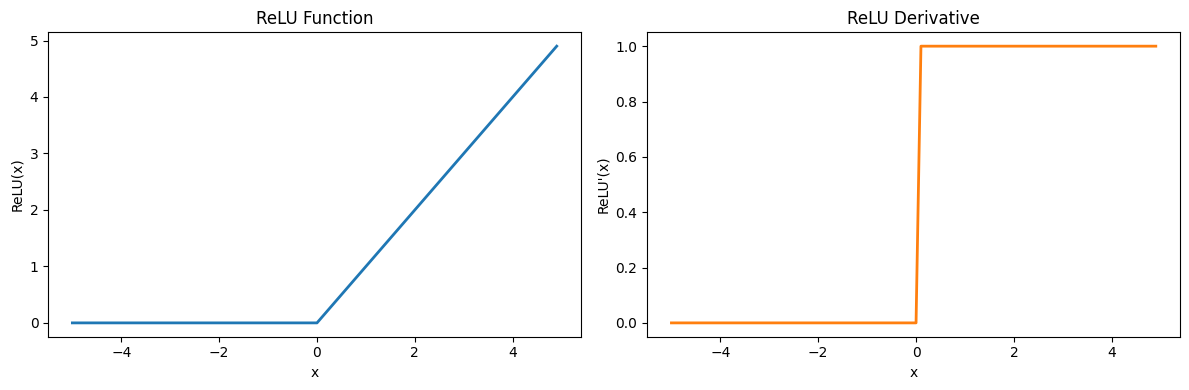

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    """ReLU导数（x=0处取0）"""
    return np.where(x > 0, 1, 0)

# 生成数据
x = np.arange(-5, 5, 0.1)
y_relu = relu(x)
y_deriv = relu_derivative(x)

# 绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ReLU曲线
ax1.plot(x, y_relu, color='#1f77b4', linewidth=2)
ax1.set_title('ReLU Function')
ax1.set_xlabel('x')
ax1.set_ylabel('ReLU(x)')
ax1.grid(False)

# 导数曲线
ax2.plot(x, y_deriv, color='#ff7f0e', linewidth=2)
ax2.set_title('ReLU Derivative')
ax2.set_xlabel('x')
ax2.set_ylabel('ReLU\'(x)')
ax2.grid(False)

plt.tight_layout()
plt.show()

- 优点：不存在梯度消失问题，计算成本很低，收敛速度比 sigmoid 和 tanh 函数快得多。
- 缺点：当梯度值过大时，其权重更新后为负数，在 ReLU 函数中导数恒为零，导致后面的梯度也不再更新，也被称为 dying ReLU 问题。

### 1.4 线性激活函数  
线性激活的输出是输入值本身，按原样输出输入值：  

$$linear(x) = x$$

使用python实现此函数:

In [31]:
def linear(x):
    return x

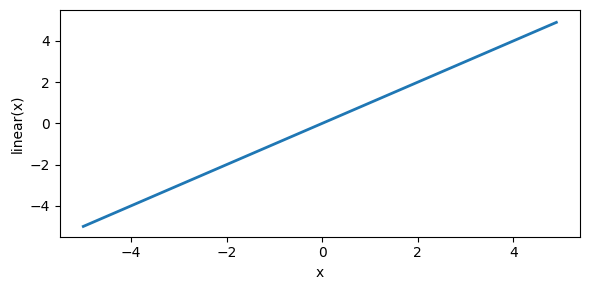

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 定义线性激活函数
def linear(x):
    """线性激活函数 f(x) = x"""
    return x

# 生成x轴数据（参考图范围：-5到5，步长0.1）
x = np.arange(-5, 5, 0.1)
y = linear(x)

# 绘制线性函数曲线（还原参考图的极简风格）
plt.figure(figsize=(6, 3))  # 比例接近参考图
plt.plot(x, y, color='#1f77b4', linewidth=2)  # 蓝色曲线，可换色

# 设置图表样式（匹配参考图的简洁布局）
plt.xlabel('x')
plt.ylabel('linear(x)')
plt.ylim(-5.5, 5.5)  # y轴范围和x轴一致，符合线性函数特征
plt.grid(False)      # 关闭网格，和参考图一致
plt.tight_layout()   # 紧凑布局

# 显示图像
plt.show()

该函数仅用于解决回归问题的神经网络模型的输出层，注意不能在隐藏层中使用线性激活函数。

### 1.5 Softmax激活函数  
通常，softmax 在神经网络输出最终结果前使用。通常使用 softmax 是为了确定输入在给定场景中属于 n 个可能的输出类别之一的概率。假设我们正在尝试将数字图像分类为可能的 10 类(数字从0到9)之一。在这种情况下，有 10 个输出值，其中每个输出值代表输入图像属于某个类别的概率。Softmax 激活函数计算公式如下：

$$ p_i = \frac{e^{z_i}}{\sum_{j=0}^9 e^{z_j}} $$

softmax 激活用于为输出中的每个类别提供一个概率值，使用 Python 实现此函数：

In [33]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x))

softmax 函数一般作为神经网络的最后一层，接受来自上一层网络的输入值，然后将其转化为概率。例如我们要识别一张图片，其可能的标签为 [apple, banana, lemon, pear]，则网络最后一层值 [1.0, 2.0, 3.0, 4.0] 经过 softmax 函数后输出为 [0.0320586, 0.08714432, 0.23688282, 0.64391426]。

## 2. 常用损失函数  
利用损失函数计算损失值，模型就可以通过反向传播去更新各个参数，通过降低真实值与预测值之间的损失，使得模型计算得到的预测值趋近于真实值，从而达到模型训练的目的，损失函数的选择取决于问题的类型和所需的输出结果。损失函数需要为非负实值函数。

### 2.1 均方误差  
误差是网络输出的预测值与实际值之差。我们对误差取平方，是因为误差可以是正值或负值。平方确保正误差和负误差不会相互抵消。我们计算均方误差 (Mean Square Error, MSE)，以便当两个数据集的大小不相同时，它们间的误差是可比较的。预测值 (p) 和实际值 (y) 之间的均方误差计算如下：  


$$
mse(p, y) = \frac{1}{n} \sum_{i=1}^{n} (p - y)^2
$$

使用python实现此函数：

In [34]:
def mse(p, y):
    return np.mean(np.square(p - y))

当神经网络需要预测连续值时，通常使用均方误差。

### 2.2 平均绝对误差  
平均绝对误差 (Mean Absolute Error, MAE) 的工作方式与均方误差非常相似。平均绝对误差通过对所有数据点上的实际值和预测值之间的绝对差值取平均值，从而确保正误差和负误差不会相互抵消。预测值 (p) 和实际值 (y) 之间的平均绝对误差的实现方式如下：

$$
mse(p, y) = \frac{1}{n} \sum_{i=1}^{n} |p - y|
$$

使用python实现此函数：

In [35]:
def mae(p, y):
    return np.mean(np.abs(p - y))

与均方误差相似，平均绝对误差通常用于连续变量值的预测。

### 2.3 分类交叉熵  
交叉熵是对两种不同分布(实际分布和预测分布)之间差异的度量。与上述两个损失函数不同，它被广泛用于离散值输出数据。两种分布之间的交叉熵计算如下：

$$
-(y \log_2 p + (1 - y) \log_2 (1 - p))
$$

y 是实际结果， p是预测结果。预测值 (p) 和实际值 (y) 之间的分类交叉熵的 python 实现方式如下：

In [36]:
def categorical_cross_entropy(p, y):
    return -np.sum((y*np.log2(p) + (1-y)*np.log2(1-p)))

当预测值远离实际值时，分类交叉熵损失具有较高的值，而当与实际值接近时，分类交叉熵损失具有较低的值。

### 2.4 实现自定义损失函数  
在实际场景中，我们可能必须实现针对需要解决的问题自定义损失函数，尤其是在涉及目标检测、生成对抗网络等复杂神经网络中，PyTorch 提供了通过编写函数来构建自定义损失函数的方法。

在本节中，我们将实现一个自定义损失函数，它与 nn.Module 中预构建的 MSELoss 函数功能相同。

1. 导入数据，构建数据集和DataLoader，并定义神经网络

In [37]:
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

import torch
X = torch.tensor(x).float()
Y = torch.tensor(y).float()
import torch.nn as nn
device = 'cpu'
X = X.to(device)
Y = Y.to(device)
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
class MyDataset(Dataset):
    def __init__(self,x,y):
        self.x = x.clone().detach()
        self.y = y.clone().detach()
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]
ds = MyDataset(X, Y)
dl = DataLoader(ds, batch_size=2, shuffle=True)
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2,8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8,1)
    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x
mynet = MyNeuralNet().to(device)

2. 定义自定义损失函数，将两个张量对象作为输入，计算它们的差的平方，并返回两者平方差的平均值：

In [38]:
def my_mean_squared_error(_y, y):
    loss = (_y-y)**2
    loss = loss.mean()
    return loss

3.  使用相同的输入和输出组合，调用内置的 MSELoss 函数，并将其结果与我们构建的自定义函数进行比较。

- 利用 nn.MSELoss 获取均方误差损失：

In [39]:
loss_func = nn.MSELoss()
loss_value = loss_func(mynet(X),Y)
print(loss_value)

tensor(116.3585, grad_fn=<MseLossBackward0>)


- 使用自定义损失函数 my_mean_squared_error，输出损失值：

In [40]:
print(my_mean_squared_error(mynet(X),Y))

tensor(116.3585, grad_fn=<MeanBackward0>)


## 小结  
激活函数是深度学习神经网络中的一种函数，其作用是将输入信号进行“激活”，输出一个非线性的结果，本节中，介绍了常用的激活函数包括 Sigmoid、ReLU、Softmax 等；损失函数是指在训练神经网络时，用于衡量模型预测值和真实值之间的差距的函数，本节中，介绍了常用的损失函数包括均方误差、交叉熵、对数损失等。